# Zadanie: metryki
Dla nauczonego modelu policz metryki wspomniane w poznanym module o klasyfikacji na zbiorze testowym oraz policz macierz omyłek.

Import bibliotek

In [1]:
import numpy as np
import pandas as pd
import string
import nltk
import itertools
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import CountVectorizer

import danych

In [2]:
spam_dataset = pd.read_csv('spam.csv', encoding = "ISO-8859-1", usecols=[0, 1], names=['Spam', 'Text'],skiprows=1)
spam_dataset['Spam'] = spam_dataset['Spam'].replace(['ham', 'spam'], [0, 1])

Funkcja przetwarzania tekstu

In [3]:
stopwords = nltk.corpus.stopwords.words("english")
lemmater = nltk.WordNetLemmatizer()

def przygotowanie_tekstu(text):
    cleaned = ''.join([char for char in text if char not in string.punctuation])
    clean_text = cleaned.lower()
    tokens = nltk.word_tokenize(clean_text)
    without_stop = [word for word in tokens if word not in stopwords]
    lemmatized = [lemmater.lemmatize(word) for word in without_stop]
    
    return lemmatized

Podział danych na zbiór testowy i treningowy

In [4]:
spam_dataset['Lemmatized_Text'] = spam_dataset['Text'].apply(przygotowanie_tekstu)

X = spam_dataset['Lemmatized_Text'].apply(lambda x: ' '.join(x))
y = spam_dataset['Spam'].astype('int')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [5]:

count_v2 = CountVectorizer(max_df=0.1, max_features=500)
X_count_v2 = count_v2.fit_transform(spam_dataset['Lemmatized_Text'].apply(lambda x: ' '.join(x)))
lda = LatentDirichletAllocation(n_components=7, random_state=2022,
                                learning_method='batch')
X_topics = lda.fit_transform(X_count_v2)

In [6]:
feature_names = count_v2.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    print(f'Temat: {topic_idx+1}')
    print(' '.join([feature_names[i] for i in topic.argsort()[:-5-1:-1]]))
    print()

Temat: 1
call please number claim prize

Temat: 2
im ok going lor go

Temat: 3
ur txt week free tone

Temat: 4
time come like get need

Temat: 5
free text call stop reply

Temat: 6
know dont got say thats

Temat: 7
good day love see ltgt



Funkicja do wyświetlania raportów i macierzy pomyłek

In [7]:
def raport(text ,y_pred, y_test):
    print(f"{text}")
    print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Macierz pomyłek")
    plt.show()

Pipline do modelu bez tematu

In [8]:
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_df=0.1, max_features=500)),
    ('classifier', RandomForestClassifier(random_state=42))])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)



pipline do modelu z tematem wiadomosci

In [9]:
pipeline_2 = Pipeline([
    ('count', CountVectorizer(max_df=0.1, max_features=500)),
    ('subject', LatentDirichletAllocation(n_components=7, random_state=2022, learning_method='batch'))
])

combined_features = FeatureUnion([('tfidf', TfidfVectorizer(max_df=0.1, max_features=500)),('subject', pipeline_2)])

model_pipeline_with_subject = Pipeline([('features', combined_features),('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))])
model_pipeline_with_subject.fit(X_train, y_train)
y_pred_with_subject = model_pipeline_with_subject.predict(X_test)


Raport modelu bez dodanych tematów
              precision    recall  f1-score   support

     Ham (0)       0.98      0.99      0.99       966
    Spam (1)       0.93      0.87      0.90       149

    accuracy                           0.97      1115
   macro avg       0.96      0.93      0.94      1115
weighted avg       0.97      0.97      0.97      1115



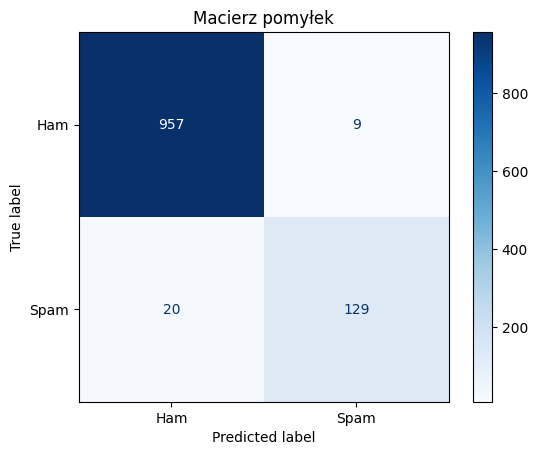

Raport modelu z dodanm tematem wiadomosci
              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99       966
    Spam (1)       1.00      0.86      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



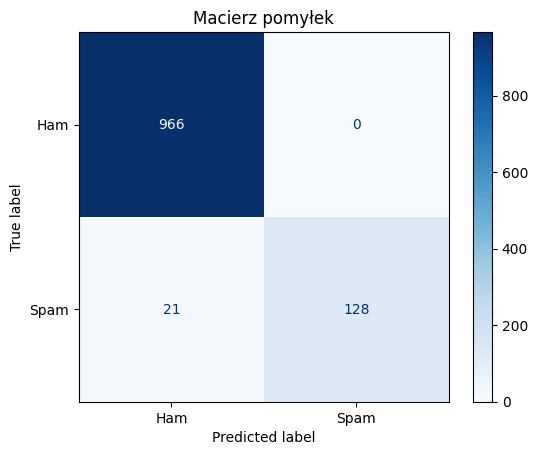

In [ ]:
raport("Raport modelu bez dodanych tematów",y_pred, y_test)
raport("Raport modelu z dodanm tematem wiadomosci",y_pred_with_subject, y_test)

Jak widać na wykresach zastosowanie LatentDirichletAllocation zdecydowanie zwiększyło accurasy a co jeszcze ważniejsze całkiem usunęło błędne przypasowanie prawdziwej wiadomości (HAM) do Spamu. Jest to bardzo istotne ponieważ lepiej zakwalifikować wiadomość SPAM do normalnych niż błędnie zakwalifikować ważna wiadomość do spamu. 